In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('../data/logistics_data.csv')
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())
print(df.head())

(1020, 15)
OrderID               str
CustomerName          str
City                  str
Country               str
FreightType           str
BookingType           str
Revenue           float64
TotalLoads          int64
DeliveryStatus        str
OnTimeDelivery       bool
DriverName            str
TruckID               str
OrderDate             str
DeliveryDate          str
TransitDays       float64
dtype: object
OrderID            0
CustomerName       0
City               0
Country            0
FreightType        0
BookingType        0
Revenue           12
TotalLoads         0
DeliveryStatus     0
OnTimeDelivery     0
DriverName        15
TruckID            0
OrderDate          0
DeliveryDate      41
TransitDays       29
dtype: int64
     OrderID      CustomerName       City  Country   FreightType  \
0  ORD-10523  Vision Logistics  São Paulo   Brazil   Air Freight   
1  ORD-10602       Blue Retail      Lagos  Nigeria  Rail Freight   
2  ORD-10526     Titan Imports    Nairobi    Kenya  R

In [2]:
df['Revenue'] = df['Revenue'].fillna(df['Revenue'].median)
df['OrderDate'] = pd.to_datetime(df['OrderDate'])
df['DeliveryDate'] = pd.to_datetime(df['DeliveryDate'])
df['TransitDays'] = df['TransitDays'].fillna(df['TransitDays'].median()).astype(int)
print(f'Duplicates: {df.duplicated().sum()}')
print(f'Null: {df.isnull().sum()}')
df['Month'] = df['OrderDate'].dt.to_period('M')
print(f"Clean dataset: {df.shape}")
df = df.drop_duplicates()
print(f"After removing duplicates: {df.shape}")
df['DriverName'] = df['DriverName'].fillna('Unknown')
df = df.dropna(subset=['DeliveryDate'])

print(df.isnull().sum())
print(df.shape)

Duplicates: 20
Null: OrderID            0
CustomerName       0
City               0
Country            0
FreightType        0
BookingType        0
Revenue            0
TotalLoads         0
DeliveryStatus     0
OnTimeDelivery     0
DriverName        15
TruckID            0
OrderDate          0
DeliveryDate      41
TransitDays        0
dtype: int64
Clean dataset: (1020, 16)


After removing duplicates: (1000, 16)
OrderID           0
CustomerName      0
City              0
Country           0
FreightType       0
BookingType       0
Revenue           0
TotalLoads        0
DeliveryStatus    0
OnTimeDelivery    0
DriverName        0
TruckID           0
OrderDate         0
DeliveryDate      0
TransitDays       0
Month             0
dtype: int64
(959, 16)


## Data Cleaning Steps

**1. Revenue missing values:** Filled 12 missing Revenue values 
with the median (£X) instead of mean to avoid distortion from outliers.

**2. Date conversion:** Converted OrderDate and DeliveryDate from 
text strings to datetime format for time-based analysis.

**3. Duplicate removal:** Found and removed 20 duplicate records 
that would have inflated metrics.

**4. Missing DriverName:** Filled 15 missing driver names with 
'Unknown' to preserve the rows for analysis.

**5. Missing DeliveryDate:** Dropped 41 rows with no delivery date 
as these cannot contribute to delivery performance analysis.

In [3]:
df['Revenue'] = pd.to_numeric(df['Revenue'], errors='coerce')
df['Revenue'] = df['Revenue'].fillna(df['Revenue'].median())
print(df['Revenue'].dtype)

float64


In [4]:
# Q1 - Revenue by Freight Type
freight_revenue = df.groupby('FreightType')['Revenue'].sum().sort_values(ascending=False)
print(freight_revenue)
print('Business insight: Revenue by freight type reveals which transport mode is the biggest revenue driver and where investment should focus.')

# Q2 - Top 10 Cities by Total Orders
top_cities = df['City'].value_counts().head(10)
print(top_cities)
print('Business insight: The top cities are our strongest markets, so prioritizing service and capacity there will reinforce growth.')

# Q3 - On-Time Delivery Rate by Freight Type
ontime_rate = df.groupby('FreightType')['OnTimeDelivery'].mean() * 100
print(ontime_rate.round(2))
print('Business insight: The freight type with the lowest on-time delivery rate needs urgent operational review because it risks customer satisfaction and retention.')

# Q4 - Top 10 Drivers by Successful Deliveries
top_drivers = df[df['DeliveryStatus'] == 'Delivered'].groupby('DriverName')['OrderID'].count().sort_values(ascending=False).head(10)
print(top_drivers)
print('Business insight: The top-performing drivers are key reliability assets, so preserving their performance and sharing their best practices will improve overall delivery success.')

# Q5 - Monthly Revenue Trend
monthly_revenue = df.groupby('Month')['Revenue'].sum()
print(monthly_revenue)
print('Business insight: The monthly revenue trend highlights demand cycles, which should inform staffing and capacity planning.')

FreightType
Sea Freight     8018387.02
Road Freight    2328624.16
Air Freight     1861051.92
Rail Freight    1253534.89
Name: Revenue, dtype: float64
Business insight: Revenue by freight type reveals which transport mode is the biggest revenue driver and where investment should focus.
City
Abuja            85
São Paulo        70
London           70
Lagos            69
Nairobi          69
Hamburg          65
Dubai            64
Port Harcourt    64
Accra            62
Johannesburg     61
Name: count, dtype: int64
Business insight: The top cities are our strongest markets, so prioritizing service and capacity there will reinforce growth.
FreightType
Air Freight     73.02
Rail Freight    59.34
Road Freight    63.84
Sea Freight     69.54
Name: OnTimeDelivery, dtype: float64
Business insight: The freight type with the lowest on-time delivery rate needs urgent operational review because it risks customer satisfaction and retention.
DriverName
Samuel Smith    17
Victor Ojo      16
Peter Musa  

## Q1 - Revenue by Freight Type
Business Insight: Identifying our highest-earning freight types highlights which transportation modes drive our core profits and where we should prioritize future asset investments.

## Q2 - Top 10 Cities by Total Orders
Business Insight: Pinpointing the top ten cities reveals our strongest geographic markets, allowing us to strategically allocate delivery capacity and marketing spend where demand is already proven.

## Q3 - On-Time Delivery Rate by Freight Type
Business Insight: Spotting the transport mode with the lowest on-time delivery rate flags critical logistics bottlenecks that require urgent operational overhauls before they damage customer retention.

## Q4 - Top 10 Drivers by Successful Deliveries
Business Insight: Recognizing our most reliable, high-performing drivers allows us to study their routes and habits so we can replicate their best practices across the entire fleet.

## Q5 - Monthly Revenue Trend
Business Insight: Mapping monthly revenue fluctuations exposes seasonal demand cycles, giving us the foresight to scale our staffing and warehouse capacity up or down before peak seasons hit.

C:\Users\HP\AppData\Local\Temp\ipykernel_6740\3614186133.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=freight_revenue.values, y=freight_revenue.index, palette='Blues_r')


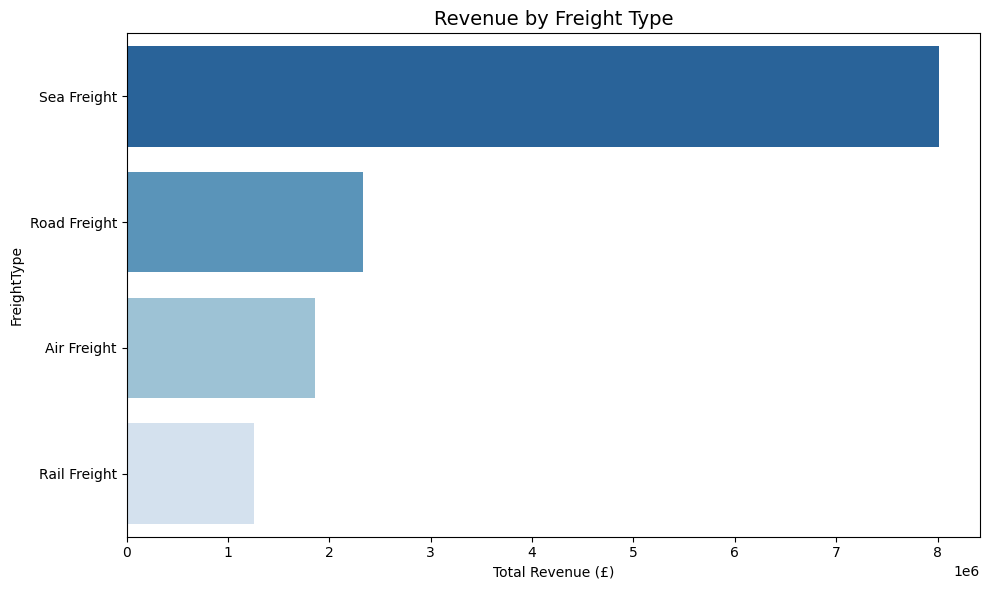

C:\Users\HP\AppData\Local\Temp\ipykernel_6740\3614186133.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_cities.values, y=top_cities.index, palette='Greens_r')


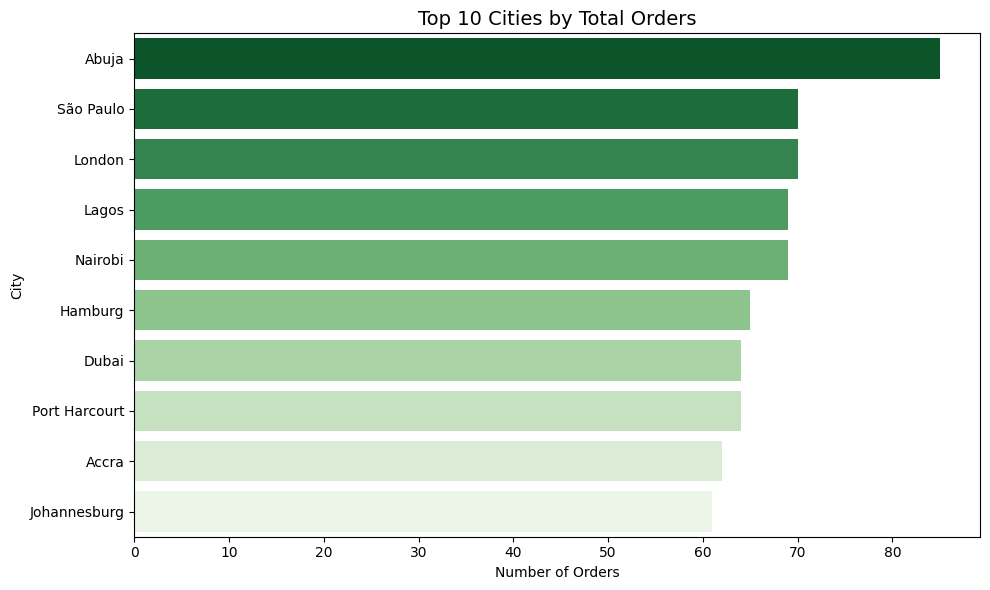

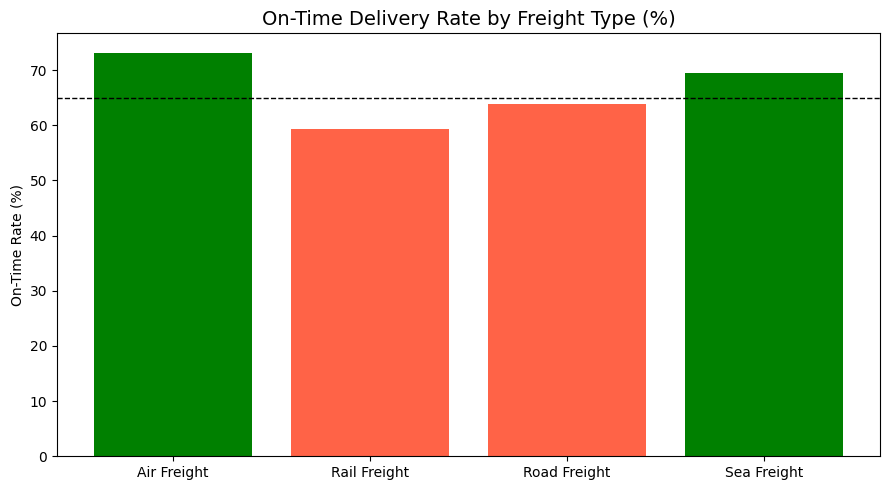

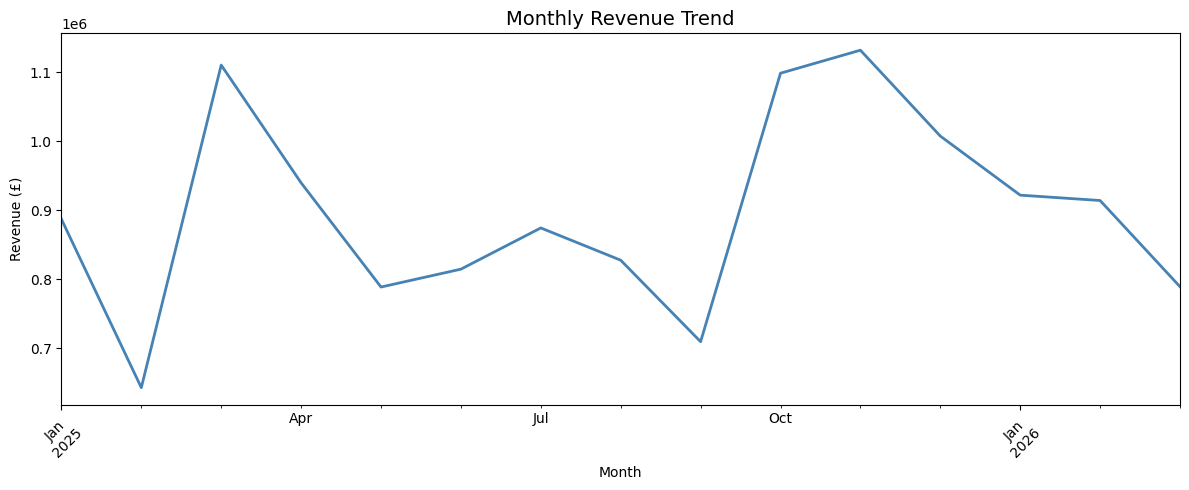

In [5]:
# Chart 1 - Revenue by Freight Type
plt.figure(figsize=(10,6))
sns.barplot(x=freight_revenue.values, y=freight_revenue.index, palette='Blues_r')
plt.title('Revenue by Freight Type', fontsize=14)
plt.xlabel('Total Revenue (£)')
plt.tight_layout()
plt.savefig('../visuals/revenue_by_freight.png')
plt.show()

# Chart 2 - Top 10 Cities
plt.figure(figsize=(10,6))
sns.barplot(x=top_cities.values, y=top_cities.index, palette='Greens_r')
plt.title('Top 10 Cities by Total Orders', fontsize=14)
plt.xlabel('Number of Orders')
plt.tight_layout()
plt.savefig('../visuals/top_cities.png')
plt.show()

# Chart 3 - On-Time Delivery Rate
colors = ['green' if x >= 65 else 'tomato' for x in ontime_rate.values]
plt.figure(figsize=(9,5))
plt.bar(ontime_rate.index, ontime_rate.values, color=colors)
plt.title('On-Time Delivery Rate by Freight Type (%)', fontsize=14)
plt.ylabel('On-Time Rate (%)')
plt.axhline(65, color='black', linestyle='--', linewidth=1)
plt.tight_layout()
plt.savefig('../visuals/ontime_rate.png')
plt.show()

# Chart 4 - Monthly Revenue Trend
plt.figure(figsize=(12,5))
monthly_revenue.plot(kind='line', color='steelblue', linewidth=2)
plt.title('Monthly Revenue Trend', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Revenue (£)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../visuals/monthly_revenue.png')
plt.show()

In [6]:
# Export for Power BI
freight_revenue.reset_index().to_csv('../data/exports/freight_revenue.csv', index=False)
top_cities.reset_index().to_csv('../data/exports/top_cities.csv', index=False)
ontime_rate.reset_index().to_csv('../data/exports/ontime_rate.csv', index=False)
monthly_revenue.reset_index().to_csv('../data/exports/monthly_revenue.csv', index=False)

# Export main clean dataset
df.to_csv('../data/exports/logistics_clean.csv', index=False)